In [853]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tamannayadav1234567/train-test-dataset/test_opI5Wmb_N886n9d_eE68Ob0_dOXWldY.csv
/kaggle/input/datasets/tamannayadav1234567/train-test-dataset/train_SCkXwSx_cNdUk28_icK39vy_36Oa6WQ.csv


In [854]:
# Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

In [855]:
# Load data
train = pd.read_csv("/kaggle/input/datasets/tamannayadav1234567/train-test-dataset/train_SCkXwSx_cNdUk28_icK39vy_36Oa6WQ.csv")
test = pd.read_csv("/kaggle/input/datasets/tamannayadav1234567/train-test-dataset/test_opI5Wmb_N886n9d_eE68Ob0_dOXWldY.csv")

In [ ]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

###  Preprocessing

In [856]:
# Clean column names
train.columns = train.columns.str.strip().str.lower()
test.columns = test.columns.str.strip().str.lower()

# Now this will always work
test_ids = test["id"]

# Drop ID
train.drop("id", axis=1, inplace=True)
test.drop("id", axis=1, inplace=True)

In [857]:
num_cols = ["income", "claim_amount", "vintage", "num_policies"]

for col in num_cols:
    train[col] = pd.to_numeric(train[col], errors="coerce")
    test[col] = pd.to_numeric(test[col], errors="coerce")

train[num_cols] = train[num_cols].fillna(0)
test[num_cols] = test[num_cols].fillna(0)

In [858]:
# Feature Engineering

def create_features(df):
    df["income_to_claim"] = df["income"] / (df["claim_amount"] + 1)
    df["claim_to_income"] = df["claim_amount"] / (df["income"] + 1)
    df["premium_per_policy"] = df["income"] / (df["num_policies"] + 1)
    df["policy_per_year"] = df["num_policies"] / (df["vintage"] + 1)

    #  STRONG FEATURES 
    df["income_log"] = np.log1p(df["income"])
    df["claim_log"] = np.log1p(df["claim_amount"])
    df["policies_log"] = np.log1p(df["num_policies"])

    df["income_per_year"] = df["income"] / (df["vintage"] + 1)
    df["claim_per_policy"] = df["claim_amount"] / (df["num_policies"] + 1)

    df["risk_score"] = df["claim_amount"] / (df["income"] + 1)

    return df

In [859]:
y = train["cltv"]
X = train.drop("cltv", axis=1)

# Fix skew
y = np.log1p(y)

In [860]:
X = pd.get_dummies(X)
test = pd.get_dummies(test)

# Align columns
X, test = X.align(test, join="left", axis=1, fill_value=0)

In [864]:
## Handle Missing Values

X.fillna(0, inplace=True)
test.fillna(0, inplace=True)

In [867]:
# Encode Categorical Data

full = pd.concat([X, test])

for col in full.columns:
    if full[col].dtype == "object":
        le = LabelEncoder()
        full[col] = le.fit_transform(full[col].astype(str))

X = full.iloc[:len(X)]
test = full.iloc[len(X):]

In [869]:
# Train Model

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03
)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)

print("R2 Score:", r2_score(y_val, val_preds))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001015 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 294
[LightGBM] [Info] Number of data points in the train set: 71513, number of used features: 17
[LightGBM] [Info] Start training from score 11.239210
R2 Score: 0.31340195227070133


In [870]:
# Train on FULL data
model.fit(X, y)

# Predict test
test_preds = model.predict(test)

# Convert back (VERY IMPORTANT)
test_preds = np.expm1(test_preds)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 294
[LightGBM] [Info] Number of data points in the train set: 89392, number of used features: 17
[LightGBM] [Info] Start training from score 11.237349


In [873]:
# Predict on Test Data

final_preds =np.expm1(preds)

In [879]:
submission

,id,cltv
0,89393,76562.616229
1,89394,107483.998629
2,89395,81115.478013
3,89396,79036.947059
4,89397,84711.741086
...,...,...
59590,148983,43990.378766
59591,148984,43108.744917
59592,148985,85203.556290
59593,148986,80333.487530


In [852]:
from sklearn.metrics import r2_score

train_preds = np.expm1(model.predict(X))
print("Train R2:", r2_score(np.expm1(y), train_preds))

Train R2: 0.1642771910071671


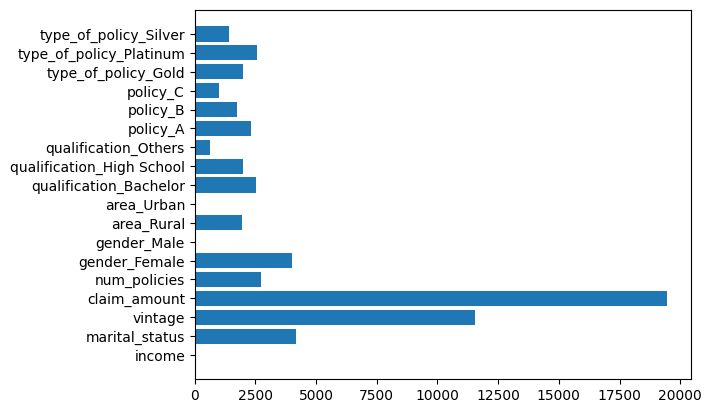

In [882]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.show()

In [887]:
# Create Submission File

submission = pd.DataFrame({
    "id": test_ids,
    "cltv": final_preds
})

submission.to_csv("submission.csv", index=False)